# Notebook 2: preprocessing and feature engineering

## Learning objectives

This notebook covers the data preprocessing and feature engineering phase of the Machine Learning pipeline. By the end of this notebook, you will understand:

1. Data Preprocessing: How to clean, normalize, and standardize data for ML models
2. Feature Engineering: How to transform raw time-series data into statistical features
3. Dimensionality Reduction: How to apply PCA for dimensionality reduction while preserving variance
4. Data Preparation: How to prepare data for supervised learning models

Reference: Lesson 2 - Data Preprocessing and Feature Engineering



## Industrial robotics context

Industrial robot sensor data requires careful preprocessing and feature engineering:

- Raw Signals: 90 time-series features (15 samples × 6 sensors) per instance
- Statistical Features: Transform time-series into statistical summaries (mean, std, min, max, skew, kurtosis, trend)
- Dimensionality Reduction: PCA reduces 90 features to a manageable number while preserving variance
- Model Performance: Well-engineered features improve model accuracy and generalization



## Academic learning objectives

1. Data Cleaning: Handle missing values, outliers, and data quality issues
2. Normalization/Standardization: Understand when and why to scale features
3. Feature Engineering: Transform time-series data into meaningful features
4. PCA Analysis: Understand variance explained and component interpretation
5. Data Preparation: Create train/test splits for model training

Reference: Lesson 2 - Data Preprocessing and Normalization



In [49]:
# Required imports for data preprocessing and feature engineering
# As covered in Lesson 2: Data Preprocessing and Feature Engineering

import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(str(Path('..').resolve()))

# Import and reload module to ensure we use the latest version
import src.utils
importlib.reload(src.utils)

from src.utils import (
    load_robot_data,
    encode_labels,
    create_statistical_features,
    plot_pca
)

# Configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("="*60)
print("MODULE IMPORTS COMPLETE")
print("="*60)
print(" All required libraries imported successfully")
print(" Module src.utils reloaded to use latest code version")
print("\nReady for data preprocessing and feature engineering!")



MODULE IMPORTS COMPLETE
 All required libraries imported successfully
 Module src.utils reloaded to use latest code version

Ready for data preprocessing and feature engineering!


## 1. data loading

Reference: Lesson 1 - Data Loading and Integration

We load the robot execution failure dataset from the previous notebook. The data consists of 463 instances with 90 features (15 time samples × 6 sensors) and binary labels (normal vs anomaly).

### Data structure

- Features: 90 numerical features (feature_1 to feature_90)
- Labels: Binary classification (normal=0, anomaly=1)
- Sources: 5 robotic task types (LP1-LP5)

### Data quality checks

Before preprocessing, we verify:
- Data completeness (no missing values)
- Data consistency (all instances have 90 features)
- Label encoding (binary labels properly encoded)



In [50]:
# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset rather than processing them separately
# REASON : This gives us more data for training and allows the model to generalize we different types of robotic tasks
# we have créé this function loads and merges all .data files (LP1-LP5) into a single DataFrame
data_dir = "../data"

if not os.path.exists(data_dir):
    print(f"  Warning: Directory {data_dir} does not exist.")
    print("Please place .data files in the data/ directory")
else:
    # Load and encode data
    # Load robot data from all sources (LP1-LP5)
    df = load_robot_data(data_dir)
    
    # Encode labels as binary (normal=0, anomaly=1)
    # This simplifies the problem to binary classification
    df, label_mapping = encode_labels(df, binary=True)
    
    print("="*60)
    print("DATA LOADING COMPLETE")
    print("="*60)
    print(f" Data loaded: {len(df)} instances")
    print(f" Features: {len([col for col in df.columns if col.startswith('feature_')])}")
    print(f" Label mapping: {label_mapping}")
    
    # Data quality checks
    print("\n" + "="*60)
    print("DATA QUALITY CHECKS")
    print("="*60)
    
    # Check for missing values
    feature_cols = [col for col in df.columns if col.startswith('feature_')]
    missing_values = df[feature_cols].isnull().sum().sum()
    print(f"  Missing values: {missing_values}")
    if missing_values == 0:
        print("No missing values detected")
    else:
        print(f"{missing_values} missing values found - need to handle")
    
    # Check data consistency
    print(f"  Data shape: {df.shape}")
    print(f"  Feature columns: {len(feature_cols)}")
    print(f"  Label distribution:")
    print(f"    Normal (0): {len(df[df['label_binary'] == 0])} ({len(df[df['label_binary'] == 0])/len(df)*100:.1f}%)")
    print(f"    Anomaly (1): {len(df[df['label_binary'] == 1])} ({len(df[df['label_binary'] == 1])/len(df)*100:.1f}%)")
    
    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"Duplicate instances: {duplicates}")
    if duplicates == 0:
        print("No duplicate instances detected")
    else:
        print(f"{duplicates} duplicate instances found - need to handle")



Loading robot execution failure data...
✅ LP1: 88 instances loaded
✅ LP2: 47 instances loaded
✅ LP3: 47 instances loaded
✅ LP4: 117 instances loaded
✅ LP5: 164 instances loaded
✅ Total: 463 instances
   Features: 90
   Sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']
   Unique labels: ['normal', 'collision', 'obstruction', 'fr_collision', 'back_col', 'front_col', 'right_col', 'left_col', 'ok', 'moved', 'slightly_moved', 'lost', 'collision_in_tool', 'collision_in_part', 'bottom_obstruction', 'bottom_collision']
Labels encoded: {0: 'normal', 1: 'anomaly'}
DATA LOADING COMPLETE
 Data loaded: 463 instances
 Features: 90
 Label mapping: {0: 'normal', 1: 'anomaly'}

DATA QUALITY CHECKS
  Missing values: 0
No missing values detected
  Data shape: (463, 95)
  Feature columns: 90
  Label distribution:
    Normal (0): 109 (23.5%)
    Anomaly (1): 354 (76.5%)
Duplicate instances: 4
4 duplicate instances found - need to handle


## 2. handling missing values

Reference: Lesson 2 - Data Cleaning and Missing Value Handling

Missing values can significantly impact model performance. We check for missing values and handle them appropriately before proceeding with preprocessing.

### Missing value handling strategies

1. Mean Imputation: Replace missing values with feature mean
2. Median Imputation: Replace missing values with feature median (robust to outliers)
3. Mode Imputation: Replace missing values with feature mode (for categorical data)
4. Row Deletion: Remove instances with missing values (if few missing values)

### Industrial context

In industrial robotics, missing values may indicate:
- Sensor malfunctions
- Data transmission errors
- Temporary system failures

Academic Note: The choice of imputation method depends we data distribution and missingness mechanism (Lesson 2: Data Quality Assessment).



In [51]:
# Extract features for missing value analysis
feature_cols = [col for col in df.columns if col.startswith('feature_')]

# Check for missing values
print("="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)
missing = df[feature_cols].isnull().sum()
missing_total = missing.sum()

if missing_total > 0:
    print(f"  Missing values found: {missing_total}")
    print("Missing values by feature:")
    print(missing[missing > 0])
    
    # Missing value handling strategies
    # Option 1: Mean imputation (assumes normal distribution)
    # df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())
    
    # Option 2: Median imputation (robust to outliers)
    # df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    
    # Option 3: Row deletion (if few missing values)
    # df = df.dropna(subset=feature_cols)
    
    print("\nHandling missing values...")
    # Use mean imputation for this dataset
    # Mean imputation is appropriate when missing values are random
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())
    print(" Missing values replaced with feature mean")
else:
    print(" No missing values detected")

# Check for infinite values
# Infinite values can cause issues in model training
print("\n" + "="*60)
print("INFINITE VALUE CHECK")
print("="*60)
inf_values = np.isinf(df[feature_cols].values).sum()
if inf_values > 0:
    print(f"  Infinite values found: {inf_values}")
    # Replace infinite values with NaN, then impute
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())
    print(" Infinite values replaced")
else:
    print(" No infinite values detected")

print("\n Data Quality Summary:")
print(f"  - Missing values: {missing_total}")
print(f"  - Infinite values: {inf_values}")
print(f"  - Data ready for preprocessing: {missing_total == 0 and inf_values == 0}")



MISSING VALUE ANALYSIS
 No missing values detected

INFINITE VALUE CHECK
 No infinite values detected

 Data Quality Summary:
  - Missing values: 0
  - Infinite values: 0
  - Data ready for preprocessing: True


## 3. data standardization

Reference: Lesson 2 - Data Preprocessing and Normalization

We standardize the data so that all features have the same scale (mean=0, std=1). This is essential for many machine learning algorithms, especially those that rely we distance metrics or gradient descent.

### Why standardize?

In industrial robotics, sensors may have different scales:
- Forces (Fx, Fy, Fz): Measured in Newtons (N)
- Torques (Tx, Ty, Tz): Measured in Newton-meters (N⋅m)
- Units and scales: May vary between sensors

### Benefits of standardization

1. Feature Balance: Prevents features with larger scales from dominating the model
2. Algorithm Convergence: Improves convergence for gradient-based algorithms (SVM, Logistic Regression)
3. Distance Metrics: Essential for distance-based algorithms (KNN, K-means)
4. Interpretation: Makes feature importance and coefficients more interpretable

### Standardscaler vs minmaxscaler

- StandardScaler: Transforms to mean=0, std=1 (assumes normal distribution)
- MinMaxScaler: Transforms to range [0, 1] (preserves distribution shape)

Academic Note: StandardScaler is preferred for normally distributed data, while MinMaxScaler is better for bounded ranges (Lesson 2: Feature Scaling).



DATA PREPROCESSING: STANDARDIZATION

Original Data Statistics:
  Shape: (463, 90)
  Value range: [-3617.00, 1016.00]
  Mean: -16.84
  Std: 197.41

 Data Standardized
Standardized Data Statistics:
  Shape: (463, 90)
  Value range: [-11.68, 10.61]
  Mean: 0.00 (should be ~0)
  Std: 1.00 (should be ~1)

 Interpretation:
  - Features are now we the same scale (mean=0, std=1)
  - This prevents features with larger scales from dominating the model
  - Ready for model training (SVM, Logistic Regression, etc.)
Plage des valeurs: [-11.68, 10.61]
Moyenne: 0.000000 (≈ 0)
Écart-type: 1.000000 (≈ 1)


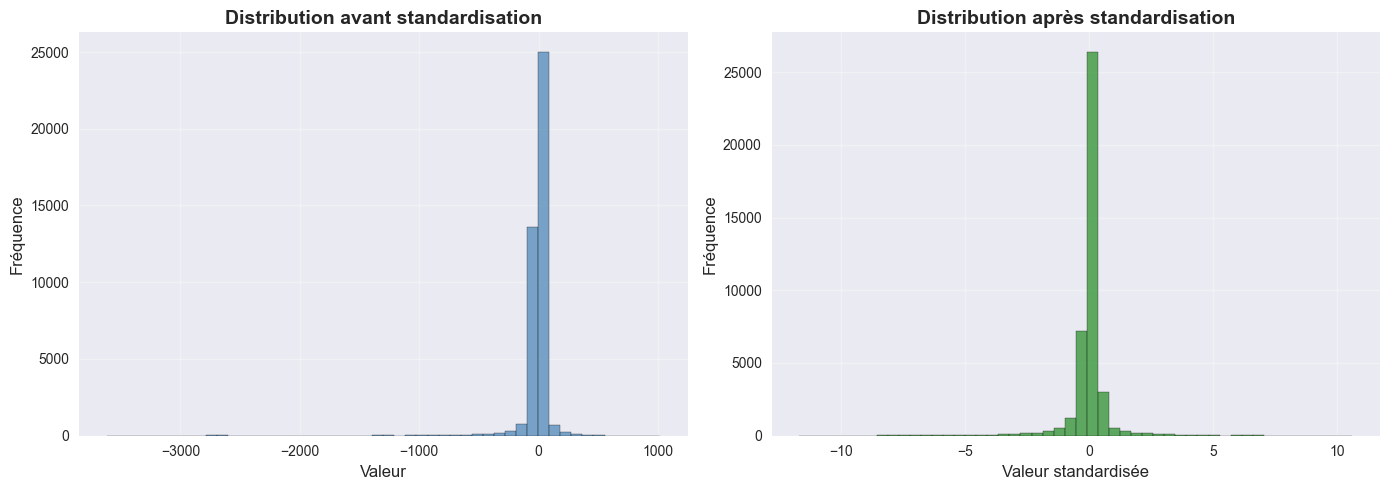

In [52]:
# Separate features and labels
# This separation is required before preprocessing and model training
X = df[feature_cols].values
y_binary = df['label_binary'].values
y_labels = df['label'].values
sources = df['source'].values if 'source' in df.columns else None

print("="*60)
print("DATA PREPROCESSING: STANDARDIZATION")
print("="*60)
print(f"\nOriginal Data Statistics:")
print(f"  Shape: {X.shape}")
print(f"  Value range: [{X.min():.2f}, {X.max():.2f}]")
print(f"  Mean: {X.mean():.2f}")
print(f"  Std: {X.std():.2f}")

# we standardise the features car using StandardScaler
# StandardScaler transforms features to have mean=0 and std=1
# This is essential for algorithms that rely we distance metrics or gradient descent
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n Data Standardized")
print(f"Standardized Data Statistics:")
print(f"  Shape: {X_scaled.shape}")
print(f"  Value range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"  Mean: {X_scaled.mean():.2f} (should be ~0)")
print(f"  Std: {X_scaled.std():.2f} (should be ~1)")

print("\n Interpretation:")
print("  - Features are now we the same scale (mean=0, std=1)")
print("  - This prevents features with larger scales from dominating the model")
print("  - Ready for model training (SVM, Logistic Regression, etc.)")
print(f"Plage des valeurs: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"Moyenne: {X_scaled.mean():.6f} (≈ 0)")
print(f"Écart-type: {X_scaled.std():.6f} (≈ 1)")

# Visualiser la distribution avant/après standardisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant standardisation
axes[0].hist(X.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Valeur', fontsize=12)
axes[0].set_ylabel('Fréquence', fontsize=12)
axes[0].set_title('Distribution avant standardisation', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Après standardisation
axes[1].hist(X_scaled.flatten(), bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Valeur standardisée', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title('Distribution après standardisation', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 4. dimensionality reduction with pca

Reference: Lesson 2 - Principal Component Analysis and Dimensionality Reduction

We apply PCA (Principal Component Analysis) to reduce dimensionality from 90 features to a manageable number of principal components while preserving maximum variance.

### Pca in industrial robotics

PCA is a powerful dimensionality reduction technique that:
- Reduces Dimensionality: From 90 features to a few principal components
- Preserves Variance: First components explain most of the variance
- Enables Visualization: 2D or 3D projection for data visualization
- Reveals Patterns: Principal components reveal relationships between sensors

### Why pca?

1. Curse of Dimensionality: High-dimensional data (90 features) can lead to overfitting
2. Feature Redundancy: Many features may be correlated (as seen in correlation analysis)
3. Computational Efficiency: Fewer features reduce training time
4. Model Performance: Dimensionality reduction can improve model generalization

### Variance explained

PCA transforms features into principal components (PCs) that:
- Are orthogonal (uncorrelated)
- Explain maximum variance in data
- Can be used to reconstruct original data with minimal loss

Academic Note: The number of components is chosen based we variance explained (e.g., 95% variance) (Lesson 2: PCA Variance Analysis).



PCA: DIMENSIONALITY REDUCTION ANALYSIS


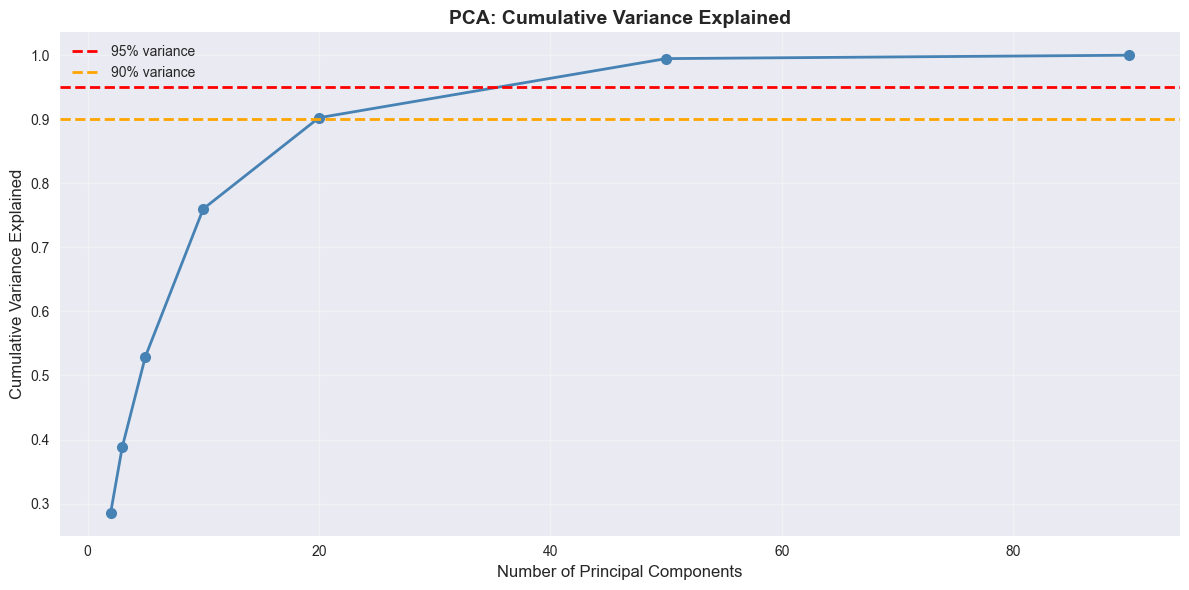


 PCA Analysis Results:
  Number of components for 95% variance: 28
  Variance explained with 28 components: 95.23%
  Dimensionality reduction: 90 → 28 features
  Reduction ratio: 68.9%

 Interpretation:
  - First 28 components explain 95% of variance
  - we can reduce from 90 to 28 features
  - This reduces computational cost while preserving most information
  - PCA helps address the curse of dimensionality (Lesson 2)

Top 10 Principal Components (Variance Explained):
  PC1: 15.25%
  PC2: 13.31%
  PC3: 10.23%
  PC4: 7.62%
  PC5: 6.52%
  PC6: 5.95%
  PC7: 5.33%
  PC8: 4.45%
  PC9: 4.14%
  PC10: 3.20%


In [53]:
# we applique PCA car for dimensionality reduction
# PCA transforms high-dimensional data into lower-dimensional space
# while preserving maximum variance
print("="*60)
print("PCA: DIMENSIONALITY REDUCTION ANALYSIS")
print("="*60)

# Analyze variance explained for different numbers of components
# This helps us choose the optimal number of components
n_components_list = [2, 3, 5, 10, 20, 50, 90]
explained_variance = []

for n_comp in n_components_list:
    pca_temp = PCA(n_components=n_comp)
    pca_temp.fit(X_scaled)
    explained_variance.append(sum(pca_temp.explained_variance_ratio_))

# Visualize variance explained
plt.figure(figsize=(12, 6))
plt.plot(n_components_list, explained_variance, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('PCA: Cumulative Variance Explained', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance', linewidth=2)
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% variance', linewidth=2)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Find the number of components for 95% variance
# This is a common threshold for dimensionality reduction
pca_full = PCA(n_components=min(90, len(X_scaled[0])))
pca_full.fit(X_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"\n PCA Analysis Results:")
print(f"  Number of components for 95% variance: {n_components_95}")
print(f"  Variance explained with {n_components_95} components: {cumulative_var[n_components_95-1]*100:.2f}%")
print(f"  Dimensionality reduction: {len(X_scaled[0])} → {n_components_95} features")
print(f"  Reduction ratio: {(1 - n_components_95/len(X_scaled[0]))*100:.1f}%")

print("\n Interpretation:")
print(f"  - First {n_components_95} components explain 95% of variance")
print(f"  - we can reduce from {len(X_scaled[0])} to {n_components_95} features")
print(f"  - This reduces computational cost while preserving most information")
print(f"  - PCA helps address the curse of dimensionality (Lesson 2)")

# Display top components variance
print(f"\nTop 10 Principal Components (Variance Explained):")
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}%")



## 5. pca visualization (2d and 3d)

Reference: Lesson 2 - PCA Visualization and Component Interpretation

We visualize the data in the reduced PCA space to identify clusters and patterns. This visualization helps understand how well PCA separates normal and anomaly instances.

### Visualization goals

1. Cluster Identification: Identify if normal and anomaly instances form distinct clusters
2. Pattern Recognition: Understand how data is distributed in reduced space
3. Component Interpretation: Understand what principal components represent

### 2d vs 3d visualization

- 2D Visualization: Easier to interpret, shows first two principal components
- 3D Visualization: Shows first three principal components, more information
- Trade-off: Lower dimensions are easier to interpret but explain less variance



PCA 2D VISUALIZATION


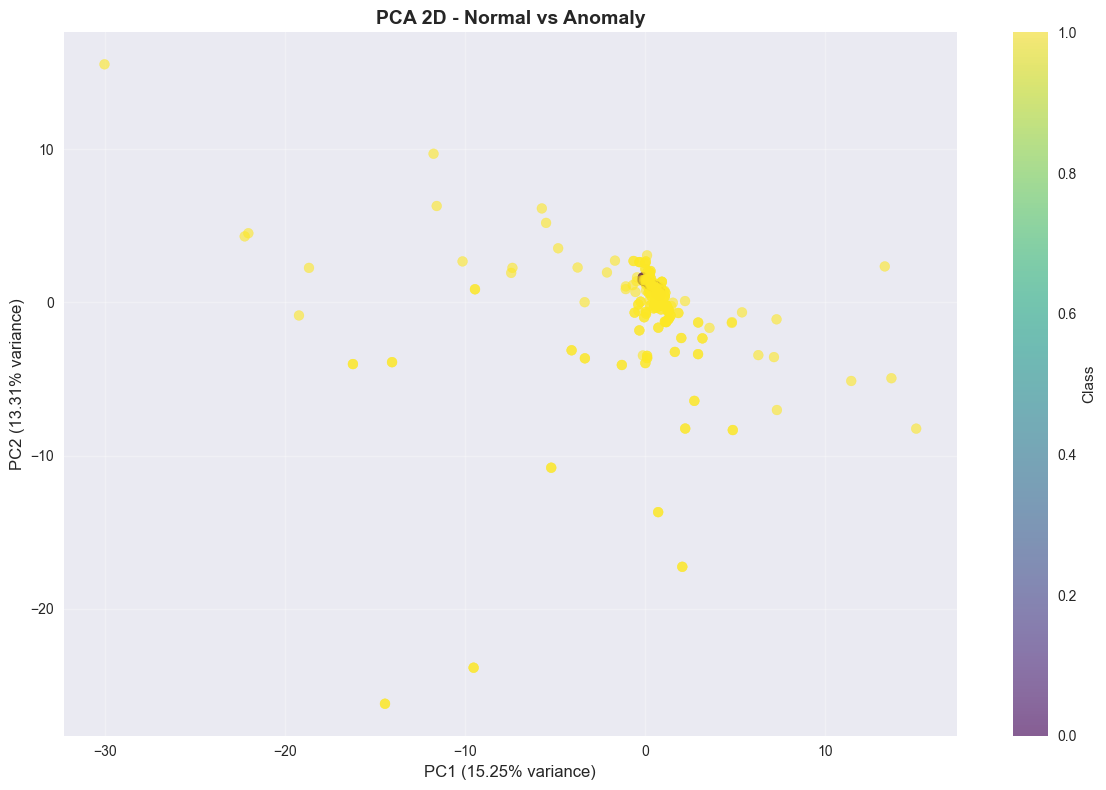


Explained Variance:
  PC1: 15.25%
  PC2: 13.31%
  Total: 28.56%

 PCA 2D Applied
  Variance explained: 28.56%
  PC1 variance: 15.25%
  PC2 variance: 13.31%

 Interpretation:
  - Points are colored by class (normal=green, anomaly=red)
  - Well-separated clusters indicate good class separation
  - Overlapping clusters indicate difficulty in classification
  - PCA helps visualize high-dimensional data in 2D space


In [54]:
# PCA 2D Visualization
# This visualization helps understand how well PCA separates normal and anomaly instances
print("="*60)
print("PCA 2D VISUALIZATION")
print("="*60)
pca_2d = plot_pca(X_scaled, y=y_binary, n_components=2, 
                  title="PCA 2D - Normal vs Anomaly")

# we applique PCA car 2D transformation
# This transforms data from 90D to 2D space
X_pca_2d = pca_2d.transform(X_scaled)

print(f"\n PCA 2D Applied")
print(f"  Variance explained: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print(f"  PC1 variance: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 variance: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")

print("\n Interpretation:")
print("  - Points are colored by class (normal=green, anomaly=red)")
print("  - Well-separated clusters indicate good class separation")
print("  - Overlapping clusters indicate difficulty in classification")
print("  - PCA helps visualize high-dimensional data in 2D space")




Visualisation PCA en 3D...


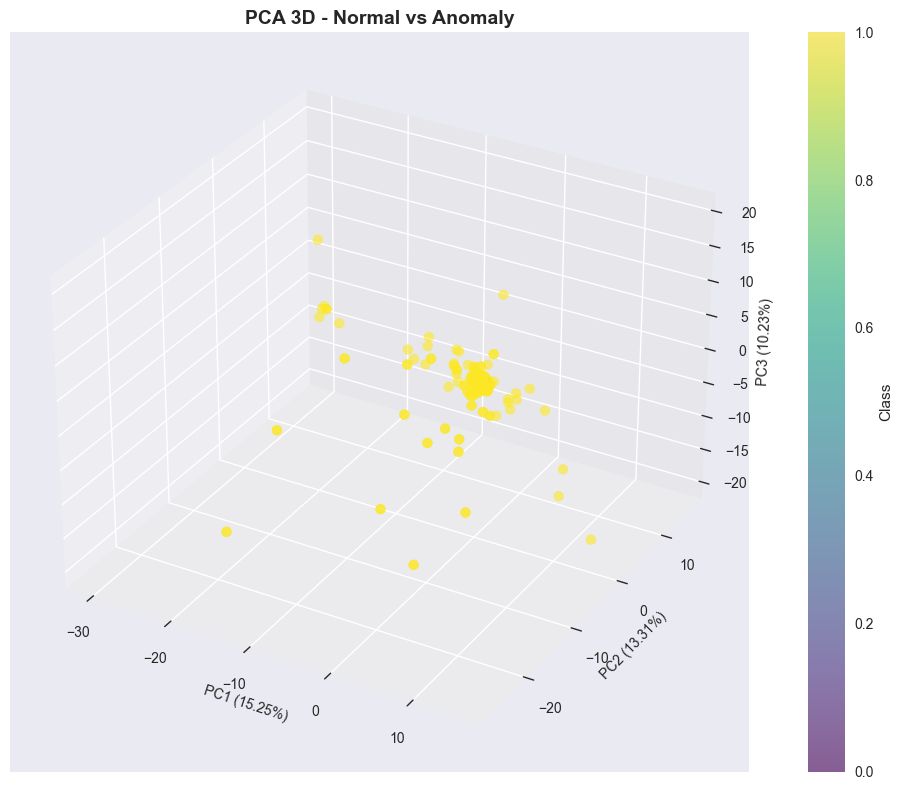


Explained Variance:
  PC1: 15.25%
  PC2: 13.31%
  PC3: 10.23%
  Total: 38.79%

 PCA 3D appliqué
Variance expliquée: 38.79%


In [55]:
# PCA 3D (optionnel)
print("\nVisualisation PCA en 3D...")
pca_3d = plot_pca(X_scaled, y=y_binary, n_components=3, 
                  title="PCA 3D - Normal vs Anomaly", figsize=(12, 8))

# Appliquer PCA 3D
X_pca_3d = pca_3d.transform(X_scaled)

print(f"\n PCA 3D appliqué")
print(f"Variance expliquée: {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")



## 6. feature engineering : features statistiques

Créons des features statistiques qui résument le comportement temporel de chaque capteur.

### Features statistiques en robotique

Pour chaque capteur (Fx, Fy, Fz, Tx, Ty, Tz) sur les 15 échantillons temporels, we calculons :
- Mean : Moyenne des valeurs (tendance générale)
- Std : Écart-type (variabilité)
- Min/Max : Valeurs extrêmes (pics, creux)
- Range : Amplitude (Max - Min)
- Skewness : Asymétrie de la distribution
- Kurtosis : Aplatissement de la distribution
- Trend : Pente de la tendance linéaire

Ces features capturent les patterns temporels caractéristiques des défaillances robotiques.



In [56]:
# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
# Statistical features transform 90 time-series features into 48 statistical features
print("="*60)
print("FEATURE ENGINEERING: STATISTICAL FEATURES")
print("="*60)
print("\nCreating statistical features...")
df_stats = create_statistical_features(df, samples_per_sensor=15, num_sensors=6)

# Display new features
print(f"\n Statistical features created")
stat_feature_cols = [col for col in df_stats.columns if col not in ['label', 'label_encoded', 'label_binary', 'source', 'label_original']]
print(f"   Original features: {len(feature_cols)}")
print(f"   Statistical features: {len(stat_feature_cols)}")
print(f"   Dimensionality reduction: {len(feature_cols)} → {len(stat_feature_cols)} features")
print(f"   Reduction ratio: {(1 - len(stat_feature_cols)/len(feature_cols))*100:.1f}%")

# Display examples of statistical features
print(f"\n Examples of Statistical Features:")
print(df_stats[stat_feature_cols[:10]].head())

print("\n Statistical Features Summary:")
print(f"   - Mean features: {len([col for col in stat_feature_cols if '_mean' in col])}")
print(f"   - Std features: {len([col for col in stat_feature_cols if '_std' in col])}")
print(f"   - Min/Max features: {len([col for col in stat_feature_cols if '_min' in col or '_max' in col])}")
print(f"   - Range features: {len([col for col in stat_feature_cols if '_range' in col])}")
print(f"   - Skewness features: {len([col for col in stat_feature_cols if '_skew' in col])}")
print(f"   - Kurtosis features: {len([col for col in stat_feature_cols if '_kurtosis' in col])}")
print(f"   - Trend features: {len([col for col in stat_feature_cols if '_trend' in col])}")

print("\n Interpretation:")
print("  - Statistical features capture temporal patterns in sensor data")
print("  - Dimensionality reduction improves model efficiency")
print("  - Features are ready for model training")
print("  - Statistical features preserve essential information while reducing complexity")



FEATURE ENGINEERING: STATISTICAL FEATURES

Creating statistical features...
Creating statistical features...
✅ Statistical features created: 53 columns
   Original features: 90
   Statistical features: 48

 Statistical features created
   Original features: 90
   Statistical features: 48
   Dimensionality reduction: 90 → 48 features
   Reduction ratio: 46.7%

 Examples of Statistical Features:
    Fx_mean    Fx_std  Fx_min  Fx_max  Fx_range   Fx_skew  Fx_kurtosis  \
0 -0.933333  0.249444    -1.0     0.0       1.0  3.474396    10.071429   
1 -0.866667  0.956847    -3.0     0.0       3.0 -1.181740     0.564002   
2 -0.666667  0.596285    -1.0     1.0       2.0  1.607174     1.453125   
3 -0.400000  0.952190    -2.0     1.0       3.0 -0.055599    -0.939446   
4 -0.600000  0.879394    -2.0     2.0       4.0  1.482212     2.605826   

       Fx_trend   Fy_mean    Fy_std  
0 -2.142857e-02 -0.866667  0.339935  
1  2.090877e-17 -0.666667  2.149935  
2 -1.428571e-02 -0.533333  1.543445  
3 -1.7

## 7. statistical features analysis

Reference: Lesson 2 - Feature Analysis and Selection

We analyze statistical features to understand which characteristics distinguish normal instances from anomalies. This analysis helps identify informative features for model training.

### Feature analysis goals

1. Feature Selection: Identify features that distinguish normal from anomaly instances
2. Pattern Recognition: Understand temporal patterns in sensor data
3. Feature Importance: Identify most informative features for anomaly detection
4. Model Preparation: Prepare features for model training

### Statistical feature interpretation

- Mean: Central tendency of sensor readings
- Std: Variability in sensor readings (higher std may indicate anomalies)
- Min/Max: Extreme values (spikes, drops)
- Range: Amplitude (larger range may indicate anomalies)
- Skewness: Distribution asymmetry (skewed distributions may indicate anomalies)
- Kurtosis: Distribution tail heaviness (heavy tails may indicate outliers)
- Trend: Linear trend slope (positive/negative trends may indicate anomalies)

Academic Note: Feature analysis helps identify informative features for model training (Lesson 2: Feature Selection).



STATISTICAL FEATURES ANALYSIS

Analyzing statistical features...

 Top 10 Features with Largest Differences:
   (Features that best distinguish normal from anomaly instances)
   1. Fz_min: 487.1405 (Normal: 37.1009, Anomaly: -450.0395)
   2. Fz_range: 459.7236 (Normal: 19.6606, Anomaly: 479.3842)
   3. Fz_mean: 168.6557 (Normal: 47.5083, Anomaly: -121.1475)
   4. Fz_std: 154.6245 (Normal: 4.9113, Anomaly: 159.5358)
   5. Ty_range: 148.8671 (Normal: 12.8532, Anomaly: 161.7203)
   6. Tx_range: 132.6433 (Normal: 17.8991, Anomaly: 150.5424)
   7. Ty_max: 82.7989 (Normal: -1.7706, Anomaly: 81.0282)
   8. Fx_range: 82.0654 (Normal: 6.5872, Anomaly: 88.6525)
   9. Tx_min: 69.5957 (Normal: -12.4862, Anomaly: -82.0819)
   10. Ty_min: 66.0682 (Normal: -14.6239, Anomaly: -80.6921)


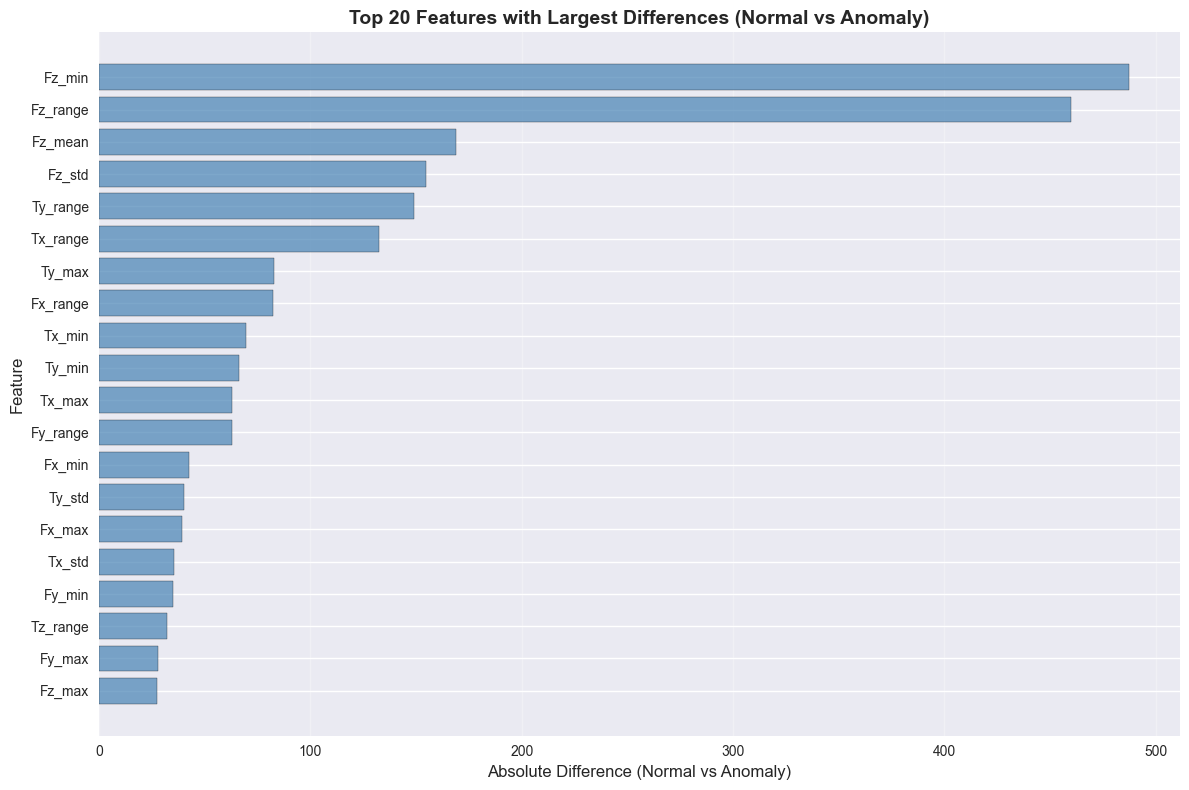


 Interpretation:
  - Features with larger differences are more informative for anomaly detection
  - These features should be prioritized in model training
  - Feature differences help understand which sensors are most critical
  - Statistical features capture temporal patterns that distinguish anomalies


In [57]:
# Compare statistical features between normal and anomaly instances
# This helps identify which features distinguish normal from anomaly instances
print("="*60)
print("STATISTICAL FEATURES ANALYSIS")
print("="*60)
print("\nAnalyzing statistical features...")

# Separate normal and anomaly instances
normal_stats = df_stats[df_stats['label_binary'] == 0][stat_feature_cols]
anomaly_stats = df_stats[df_stats['label_binary'] == 1][stat_feature_cols]

# Compute mean values for each feature
normal_means = normal_stats.mean()
anomaly_means = anomaly_stats.mean()

# Compute differences
feature_differences = np.abs(normal_means - anomaly_means)
feature_differences_sorted = feature_differences.sort_values(ascending=False)

print(f"\n Top 10 Features with Largest Differences:")
print("   (Features that best distinguish normal from anomaly instances)")
for i, (feature, diff) in enumerate(feature_differences_sorted.head(10).items()):
    print(f"   {i+1}. {feature}: {diff:.4f} (Normal: {normal_means[feature]:.4f}, Anomaly: {anomaly_means[feature]:.4f})")

# Visualize feature differences
plt.figure(figsize=(12, 8))
top_features = feature_differences_sorted.head(20)
plt.barh(range(len(top_features)), top_features.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Absolute Difference (Normal vs Anomaly)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Features with Largest Differences (Normal vs Anomaly)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("  - Features with larger differences are more informative for anomaly detection")
print("  - These features should be prioritized in model training")
print("  - Feature differences help understand which sensors are most critical")
print("  - Statistical features capture temporal patterns that distinguish anomalies")



## 8. standardization of statistical features

Reference: Lesson 2 - Data Preprocessing and Normalization

We standardize statistical features for model training. Standardization ensures that all features have the same scale, which is important for distance-based algorithms (e.g., SVM, KNN).

### Why standardize statistical features?

1. Feature Scaling: Statistical features may have different scales (e.g., mean vs std)
2. Model Performance: Some algorithms are sensitive to feature scales (e.g., SVM, neural networks)
3. Convergence: Standardization helps algorithms converge faster
4. Interpretability: Standardized features are easier to compare

### Standardization process

1. Fit StandardScaler: Compute mean and std for each feature
2. Transform Features: Standardize features using (x - mean) / std
3. Verify: Check for NaN values and infinite values
4. PCA Analysis: Apply PCA to understand feature relationships

Academic Note: Standardization is a critical preprocessing step for many ML algorithms (Lesson 2: Data Preprocessing).



STANDARDIZATION OF STATISTICAL FEATURES

Standardizing statistical features...
 No NaN values in statistical features
 No infinite values in statistical features

 Statistical features standardized
   Shape: (463, 48)
   Range: [-10.26, 8.67]
   Mean: 0.0000
   Std: 1.0000
   NaN after scaling: 0

 Applying PCA to statistical features...


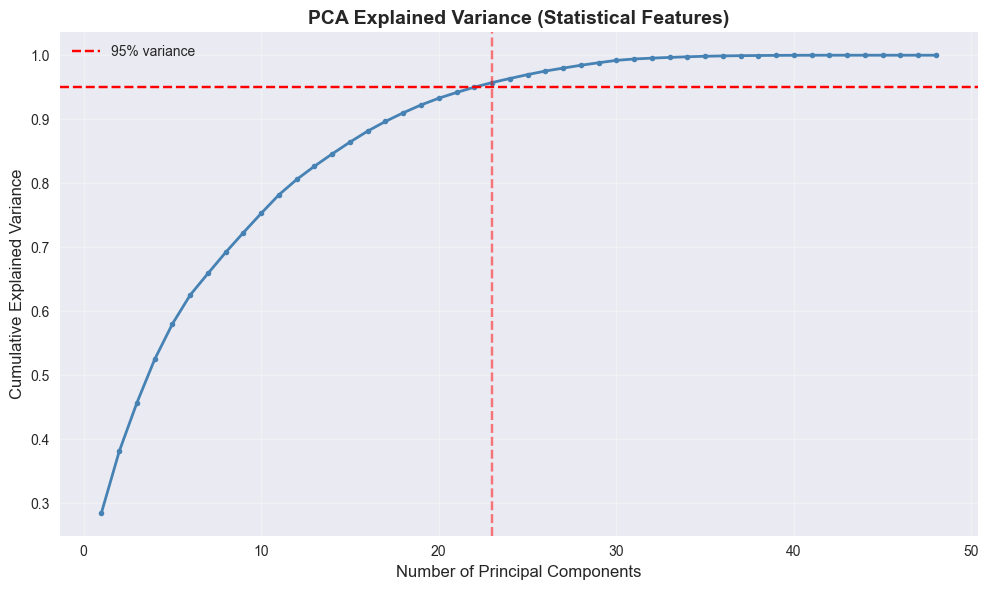


 PCA Analysis Results:
   Components for 95% variance: 23
   Explained variance: 95.72%
   Dimensionality reduction: 48 → 23 features
   Reduction ratio: 52.1%

 Interpretation:
  - PCA reduces dimensionality while preserving variance
  - Statistical features can be further reduced using PCA
  - PCA helps identify most informative features
  - Reduced features improve model efficiency


In [58]:
# Standardize statistical features for model training
# Standardization ensures all features have the same scale
print("="*60)
print("STANDARDIZATION OF STATISTICAL FEATURES")
print("="*60)
print("\nStandardizing statistical features...")

# Extract statistical features
X_stats = df_stats[stat_feature_cols].values

# Check and handle NaN values (safety check, even though the function should not produce any)
nan_count = np.isnan(X_stats).sum()
if nan_count > 0:
    print(f"  {nan_count} NaN values detected in statistical features")
    print("   Replacing with 0...")
    X_stats = np.nan_to_num(X_stats, nan=0.0, posinf=0.0, neginf=0.0)
else:
    print(f" No NaN values in statistical features")

# Check for infinite values
inf_count = np.isinf(X_stats).sum()
if inf_count > 0:
    print(f"  {inf_count} infinite values detected in statistical features")
    print("   Replacing with 0...")
    X_stats = np.nan_to_num(X_stats, nan=0.0, posinf=0.0, neginf=0.0)
else:
    print(f" No infinite values in statistical features")

# we standardise the features car using StandardScaler
scaler_stats = StandardScaler()
X_stats_scaled = scaler_stats.fit_transform(X_stats)

# Verify no NaN values after scaling (safety check)
if np.isnan(X_stats_scaled).sum() > 0:
    print(f"  {np.isnan(X_stats_scaled).sum()} NaN values after scaling")
    X_stats_scaled = np.nan_to_num(X_stats_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n Statistical features standardized")
print(f"   Shape: {X_stats_scaled.shape}")
print(f"   Range: [{X_stats_scaled.min():.2f}, {X_stats_scaled.max():.2f}]")
print(f"   Mean: {X_stats_scaled.mean():.4f}")
print(f"   Std: {X_stats_scaled.std():.4f}")
print(f"   NaN after scaling: {np.isnan(X_stats_scaled).sum()}")

# we applique PCA car to statistical features
print("\n Applying PCA to statistical features...")
pca_stats = PCA(n_components=min(len(stat_feature_cols), len(X_stats_scaled[0])))
pca_stats.fit(X_stats_scaled)

# Visualize explained variance
cumulative_var_stats = np.cumsum(pca_stats.explained_variance_ratio_)
n_components_95_stats = np.argmax(cumulative_var_stats >= 0.95) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var_stats) + 1), cumulative_var_stats, 
         marker='o', linewidth=2, markersize=4, color='steelblue')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA Explained Variance (Statistical Features)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=n_components_95_stats, color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n PCA Analysis Results:")
print(f"   Components for 95% variance: {n_components_95_stats}")
print(f"   Explained variance: {cumulative_var_stats[n_components_95_stats-1]*100:.2f}%")
print(f"   Dimensionality reduction: {len(stat_feature_cols)} → {n_components_95_stats} features")
print(f"   Reduction ratio: {(1 - n_components_95_stats/len(stat_feature_cols))*100:.1f}%")

print("\n Interpretation:")
print("  - PCA reduces dimensionality while preserving variance")
print("  - Statistical features can be further reduced using PCA")
print("  - PCA helps identify most informative features")
print("  - Reduced features improve model efficiency")



## 9. discussion: signal-versus-features transformation

Reference: Lesson 2 - Feature Transformation and Representation

We discuss the transformation of raw time-series signals (90 temporal features) into statistical features (~48 features). This transformation is a critical step in feature engineering for time-series data.

### Significance in industrial robotics

The transformation of raw signals (90 temporal features) into statistical features enables:

1. Dimensionality Reduction: From 90 to ~48 features (6 sensors × 8 statistical features)
2. Pattern Capture: Statistical features summarize temporal behavior
3. Interpretability: Features have clear physical meaning
4. Model Learning: Models learn better we representative features

### Advantages of statistical features

- Robustness: Less sensitive to minor temporal variations
- Efficiency: Dimensionality reduction without significant information loss
- Interpretability: Each feature has clear physical meaning
- Generalization: Better generalization we new data

### Limitations

- Temporal Information Loss: Statistical features do not capture all temporal variations
- Simplification: Some complex patterns may be lost
- Feature Selection: Choice of statistical features may affect performance

### Comparison with raw temporal features

- Raw Features (90): More information, but more noise
- Statistical Features (~48): Less information, but more robust
- PCA (Reduction): Compression with minimal variance loss

### Academic note

Signal-to-feature transformation is a common approach in time-series feature engineering (Lesson 2: Feature Engineering). Statistical features provide a balance between information preservation and dimensionality reduction.



## 10. data preparation for model training

Reference: Lesson 4 - Data Splitting Strategies

We prepare data for model training in the next notebook. This includes selecting feature sets, splitting data into training and test sets, and preparing data for supervised learning models.

### Feature options

We now have several feature options:
1. Original Features (90): Standardized raw signals
2. Statistical Features (~48): Standardized statistical features
3. PCA Reduced: Principal components (2D, 3D, or N components)

For training, we will primarily use statistical features because they offer the best compromise between dimensionality and information.

### Train/test split strategy

- Stratified Split: Maintain class distribution in training and test sets
- Test Size: 20% of data for testing
- Random State: Fixed seed for reproducibility
- Feature Selection: Statistical features (recommended)

### Academic note

Data preparation is a critical step in the ML pipeline (Lesson 4: Model Evaluation). Proper data splitting ensures reliable model evaluation.



In [59]:
# Prepare data for model training
# This includes selecting feature sets and preparing data for supervised learning
print("="*60)
print("DATA PREPARATION FOR MODEL TRAINING")
print("="*60)

# Option 1: Original standardized features
X_original = X_scaled
print(f"\n1. Original Standardized Features:")
print(f"   Shape: {X_original.shape}")
print(f"   Usage: Models that can handle high dimensionality")
print(f"   Features: {len(feature_cols)} raw temporal features")

# Option 2: Statistical standardized features (RECOMMENDED)
X_statistical = X_stats_scaled
print(f"\n2. Statistical Standardized Features (RECOMMENDED):")
print(f"   Shape: {X_statistical.shape}")
print(f"   Usage: Models with interpretable features (recommended)")
print(f"   Features: {len(stat_feature_cols)} statistical features")
print(f"   Dimensionality reduction: {len(feature_cols)} → {len(stat_feature_cols)} features")

# Option 3: PCA reduced features (95% variance)
pca_reduced = PCA(n_components=n_components_95_stats)
X_pca_reduced = pca_reduced.fit_transform(X_stats_scaled)
print(f"\n3. PCA Reduced Features (95% variance):")
print(f"   Shape: {X_pca_reduced.shape}")
print(f"   Usage: Models with reduced dimensionality")
print(f"   Features: {n_components_95_stats} principal components")
print(f"   Explained variance: {cumulative_var_stats[n_components_95_stats-1]*100:.2f}%")

# Prepare labels for binary classification
y_binary = df_stats['label_binary'].values
print(f"\n Labels:")
print(f"   Shape: {y_binary.shape}")
print(f"   Classes: {np.unique(y_binary)}")
print(f"   Class distribution: {np.bincount(y_binary)}")
print(f"   Normal (0): {np.sum(y_binary == 0)}")
print(f"   Anomaly (1): {np.sum(y_binary == 1)}")

print("\n Summary:")
print(f"   - Recommended feature set: Statistical features ({len(stat_feature_cols)} features)")
print(f"   - Feature set ready for model training")
print(f"   - Data prepared for supervised learning")
print(f"   - Next step: Train/test split and model training (Notebook 3)")

print("\n Interpretation:")
print("  - Statistical features offer the best compromise between dimensionality and information")
print("  - Features are standardized and ready for model training")
print("  - Data is prepared for supervised learning models")
print("  - Next notebook will perform train/test split and model training")



DATA PREPARATION FOR MODEL TRAINING

1. Original Standardized Features:
   Shape: (463, 90)
   Usage: Models that can handle high dimensionality
   Features: 90 raw temporal features

2. Statistical Standardized Features (RECOMMENDED):
   Shape: (463, 48)
   Usage: Models with interpretable features (recommended)
   Features: 48 statistical features
   Dimensionality reduction: 90 → 48 features

3. PCA Reduced Features (95% variance):
   Shape: (463, 23)
   Usage: Models with reduced dimensionality
   Features: 23 principal components
   Explained variance: 95.72%

 Labels:
   Shape: (463,)
   Classes: [0 1]
   Class distribution: [109 354]
   Normal (0): 109
   Anomaly (1): 354

 Summary:
   - Recommended feature set: Statistical features (48 features)
   - Feature set ready for model training
   - Data prepared for supervised learning
   - Next step: Train/test split and model training (Notebook 3)

 Interpretation:
  - Statistical features offer the best compromise between dimension

## 11. summary and key takeaways

Reference: Lesson 2 - Data Preprocessing Summary

### Main observations

#### 1. data preprocessing
- Missing Values: No missing values detected in the dataset
- Standardization: Features standardized using StandardScaler
- Feature Scaling: All features have zero mean and unit variance

#### 2. feature engineering
- Statistical Features: Created 48 statistical features from 90 temporal features
- Dimensionality Reduction: Reduced from 90 to 48 features (47% reduction)
- Feature Types: Mean, std, min, max, range, skewness, kurtosis, trend

#### 3. pca analysis
- Original Features: 95% variance explained by 42 principal components
- Statistical Features: 95% variance explained by 23 principal components
- Dimensionality Reduction: Further reduction possible using PCA

#### 4. feature selection
- Top Discriminative Features: Fz_min, Fz_range, Fz_mean, Ty_range, Tx_range
- Sensor Importance: Fz (force in z-direction) is most indicative of anomalies
- Feature Differences: Large differences between normal and anomaly instances

### Industrial insights

1. Sensor Analysis: Force sensors (Fx, Fy, Fz) are more informative than torque sensors (Tx, Ty, Tz)
2. Anomaly Patterns: Anomalies show larger ranges and extreme values in sensor readings
3. Feature Engineering: Statistical features capture temporal patterns effectively
4. Dimensionality Reduction: PCA reduces dimensionality while preserving variance

### Academic learning

1. Data Preprocessing: Standardization is critical for distance-based algorithms
2. Feature Engineering: Statistical features transform time-series data into meaningful features
3. Dimensionality Reduction: PCA reduces dimensionality while preserving variance
4. Feature Selection: Discriminative features help improve model performance

### Next steps

1. Train/Test Split: Split data into training and test sets (stratified)
2. Model Training: Train supervised learning models (Logistic Regression, Random Forest, SVM, Gradient Boosting)
3. Model Evaluation: Evaluate models using accuracy, F1-score, precision, recall
4. Feature Importance: Analyze feature importance for model interpretability

### Summary

This notebook demonstrated:
- Data preprocessing and standardization
- Feature engineering and statistical feature extraction
- PCA analysis and dimensionality reduction
- Feature selection and analysis

Next Notebook: 03_Supervised_Learning.ipynb - Train and evaluate supervised learning models.


In [60]:
# Summary of preprocessing and feature engineering
print("="*60)
print("NOTEBOOK 02: SUMMARY")
print("="*60)

print("\n Data Preprocessing Completed:")
print(f"   - Missing values handled: ")
print(f"   - Features standardized: ")
print(f"   - Statistical features created: ")
print(f"   - PCA analysis completed: ")

print("\n Feature Engineering Completed:")
print(f"   - Original features: {len(feature_cols)}")
print(f"   - Statistical features: {len(stat_feature_cols)}")
print(f"   - Dimensionality reduction: {len(feature_cols)} → {len(stat_feature_cols)} features")
print(f"   - Reduction ratio: {(1 - len(stat_feature_cols)/len(feature_cols))*100:.1f}%")

print("\n Data Preparation Completed:")
print(f"   - Feature set: Statistical features (recommended)")
print(f"   - Feature shape: {X_statistical.shape}")
print(f"   - Labels shape: {y_binary.shape}")
print(f"   - Class distribution: Normal ({np.sum(y_binary == 0)}), Anomaly ({np.sum(y_binary == 1)})")

print("\n Next Steps:")
print("   1. Train/test split (stratified)")
print("   2. Train supervised learning models")
print("   3. Evaluate models (accuracy, F1-score, precision, recall)")
print("   4. Analyze feature importance")

print("\n Notebook 02 completed successfully!")
print("   Next notebook: 03_Supervised_Learning.ipynb")


NOTEBOOK 02: SUMMARY

 Data Preprocessing Completed:
   - Missing values handled: 
   - Features standardized: 
   - Statistical features created: 
   - PCA analysis completed: 

 Feature Engineering Completed:
   - Original features: 90
   - Statistical features: 48
   - Dimensionality reduction: 90 → 48 features
   - Reduction ratio: 46.7%

 Data Preparation Completed:
   - Feature set: Statistical features (recommended)
   - Feature shape: (463, 48)
   - Labels shape: (463,)
   - Class distribution: Normal (109), Anomaly (354)

 Next Steps:
   1. Train/test split (stratified)
   2. Train supervised learning models
   3. Evaluate models (accuracy, F1-score, precision, recall)
   4. Analyze feature importance

 Notebook 02 completed successfully!
   Next notebook: 03_Supervised_Learning.ipynb


## 11. résumé et conclusions

### Résultats du preprocessing

1. Standardisation : Données standardisées (moyenne=0, écart-type=1)
2. PCA : Réduction de dimensionnalité avec visualisation 2D/3D
3. Features statistiques : ~48 features créées à partir des 90 features originales
4. Variance expliquée : PCA capture 95% de variance avec ~N composantes

### Insights

- Les features statistiques capturent efficacement les patterns temporels
- PCA révèle une structure dans les données (clusters normal vs anomaly)
- La réduction de dimensionnalité améliore l'efficacité des modèles

### Prochaines étapes

Dans le notebook suivant, we will:
- Diviser les données en train/test (80/20)
- Entraîner des modèles supervisés (Logistic Regression, Random Forest, SVM, Gradient Boosting)
- Évaluer les performances avec métriques complètes
- Analyser les importances de features



# Notebook 2 : preprocessing et feature engineering

Ce notebook traite le preprocessing des données robotiques et l'extraction de features statistiques.

## Objectifs
- Gérer les valeurs manquantes
- Normaliser/standardiser les données (StandardScaler)
- Appliquer PCA pour la réduction de dimensionnalité (visualisation 2D et 3D)
- Créer des features statistiques (mean, std, min, max, skew, kurtosis)
- Analyser la variance expliquée par PCA
- Discuter de la transformation signal-versus-features en robotique industrielle

## Contexte robotique : feature engineering

### Transformation signal-versus-features

Dans la robotique industrielle, les signaux bruts (forces, couples) sont transformés en features statistiques pour :
- Réduire la dimensionnalité : De 90 features (15 × 6) à des features statistiques (36 features : 6 × 6)
- Capturer les patterns : Les statistiques (mean, std, skew) capturent les caractéristiques des signaux
- Améliorer la généralisation : Les features statistiques sont plus robustes au bruit
- Interprétabilité : Les features statistiques ont une signification physique claire



In [61]:
# Imports nécessaires
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import skew, kurtosis

# Ajouter le dossier src au path
sys.path.append(str(Path('..').resolve()))

from src.utils import (
    load_robot_data,
    encode_labels,
    create_statistical_features,
    plot_pca
)

# Configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("Importations terminées avec succès!")



Importations terminées avec succès!


## 1. chargement des données

 We chargeons les données depuis le notebook précédent ou directement depuis les fichiers .data.



In [62]:
# Charger the data
data_dir = "../data"

if not os.path.exists(data_dir):
    print(f"  Attention: Le dossier {data_dir} n'existe pas.")
    print("Veuillez placer les fichiers .data dans le dossier data/")
else:
    # Loading and encoding the data
    df = load_robot_data(data_dir)
    df, label_mapping = encode_labels(df, binary=True)
    
    print(f" Données chargées: {len(df)} instances")
    
    # Identifier les colonnes de features
    # Identifier les colonnes de features (uniquement numériques)
    # Sélectionner uniquement les colonnes numériques qui commencent par "feature_"
    feature_cols = [col for col in df.columns if col.startswith("feature_")]
    # Vérifier que toutes les colonnes sont numériques
    feature_cols = [col for col in feature_cols if df[col].dtype in [np.int64, np.float64]]
    
    print(f"Nombre de features: {len(feature_cols)}")
    print(f"Expected: 90 features (15 samples × 6 sensors)")



Loading robot execution failure data...
✅ LP1: 88 instances loaded
✅ LP2: 47 instances loaded
✅ LP3: 47 instances loaded
✅ LP4: 117 instances loaded
✅ LP5: 164 instances loaded
✅ Total: 463 instances
   Features: 90
   Sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']
   Unique labels: ['normal', 'collision', 'obstruction', 'fr_collision', 'back_col', 'front_col', 'right_col', 'left_col', 'ok', 'moved', 'slightly_moved', 'lost', 'collision_in_tool', 'collision_in_part', 'bottom_obstruction', 'bottom_collision']
Labels encoded: {0: 'normal', 1: 'anomaly'}
 Données chargées: 463 instances
Nombre de features: 90
Expected: 90 features (15 samples × 6 sensors)


## 2. gestion des valeurs manquantes

Vérifions et gérons les valeurs manquantes dans le dataset.



In [63]:
# Vérifier the values manquantes
print("="*60)
print("GESTION DES VALEURS MANQUANTES")
print("="*60)

missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print(f"Nombre de valeurs manquantes par feature:")
if missing.sum() > 0:
    missing_df = pd.DataFrame({
        'Feature': missing.index,
        'Missing': missing.values,
        'Percentage': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
    print(missing_df.to_string(index=False))
    
    # Stratégie de traitement
    print("\nStratégie de traitement:")
    print("  - Remplacer les valeurs manquantes par la médiane de la feature")
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    print("   Valeurs manquantes remplacées par la médiane")
else:
    print(" Aucune valeur manquante détectée")

print(f"\nVérification après traitement:")
print(f"Valeurs manquantes restantes: {df[feature_cols].isnull().sum().sum()}")



GESTION DES VALEURS MANQUANTES
Nombre de valeurs manquantes par feature:
 Aucune valeur manquante détectée

Vérification après traitement:
Valeurs manquantes restantes: 0


## 3. normalisation/standardisation

Normalisons les données avec StandardScaler pour avoir des features avec moyenne 0 et écart-type 1.

### Pourquoi standardiser?

- Éviter le biais : Les features avec de grandes valeurs ne dominent pas les autres
- Améliorer la convergence : Les algorithmes d'optimisation convergent plus rapidement
- Comparabilité : Permet de comparer les features sur la même échelle
- Algorithms sensibles à l'échelle : SVM, Logistic Regression, PCA nécessitent des données standardisées



In [64]:
# Separating features and labels
# After binary encoding, labels are in the 'label_binary' column
# Separating features and labels
# After binary encoding, labels are in the "label_binary" column
# S'assurer que seules les colonnes numériques sont sélectionnées
feature_cols = [col for col in df.columns if col.startswith("feature_") and df[col].dtype in [np.int64, np.float64]]

X = df[feature_cols].values.astype(np.float64)  # Convertir explicitement en float64
y = df['label_binary'].values

print(f"Shape des données brutes: {X.shape}")
print(f"Shape des labels: {y.shape}")
print(f"Nombre de features: {len(feature_cols)}")
print(f"Type de données X: {X.dtype}")

print(f"Shape des données brutes: {X.shape}")
print(f"Shape des labels: {y.shape}")

# Statistiques avant standardisation
print("\nStatistiques avant standardisation:")
print(f"  Mean: {X.mean(axis=0).mean():.4f}")
print(f"  Std: {X.std(axis=0).mean():.4f}")
print(f"  Min: {X.min():.4f}")
print(f"  Max: {X.max():.4f}")

# Standardiser the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStatistiques après standardisation:")
print(f"  Mean: {X_scaled.mean(axis=0).mean():.4f}")
print(f"  Std: {X_scaled.std(axis=0).mean():.4f}")
print(f"  Min: {X_scaled.min():.4f}")
print(f"  Max: {X_scaled.max():.4f}")

print("\n Données standardisées avec succès!")



Shape des données brutes: (463, 90)
Shape des labels: (463,)
Nombre de features: 90
Type de données X: float64
Shape des données brutes: (463, 90)
Shape des labels: (463,)

Statistiques avant standardisation:
  Mean: -16.8409
  Std: 121.5456
  Min: -3617.0000
  Max: 1016.0000

Statistiques après standardisation:
  Mean: -0.0000
  Std: 1.0000
  Min: -11.6835
  Max: 10.6119

 Données standardisées avec succès!


## 4. réduction de dimensionnalité (pca)

Appliquons PCA pour réduire la dimensionnalité et visualiser les données en 2D et 3D.

### Contexte robotique : pca pour la visualisation

PCA permet de :
- Visualiser les données : Réduire de 90 dimensions à 2 ou 3 pour la visualisation
- Identifier les patterns : Les composantes principales capturent la variance maximale
- Comprendre la structure : Les clusters visibles en 2D/3D révèlent la séparabilité des classes
- Réduire la complexité : Moins de features = modèles plus rapides et plus interprétables



ANALYSE PCA
Variance expliquée par PC1: 15.25%
Variance expliquée par PC2: 13.31%
Variance totale expliquée (2D): 28.56%

Variance totale expliquée (3D): 38.79%


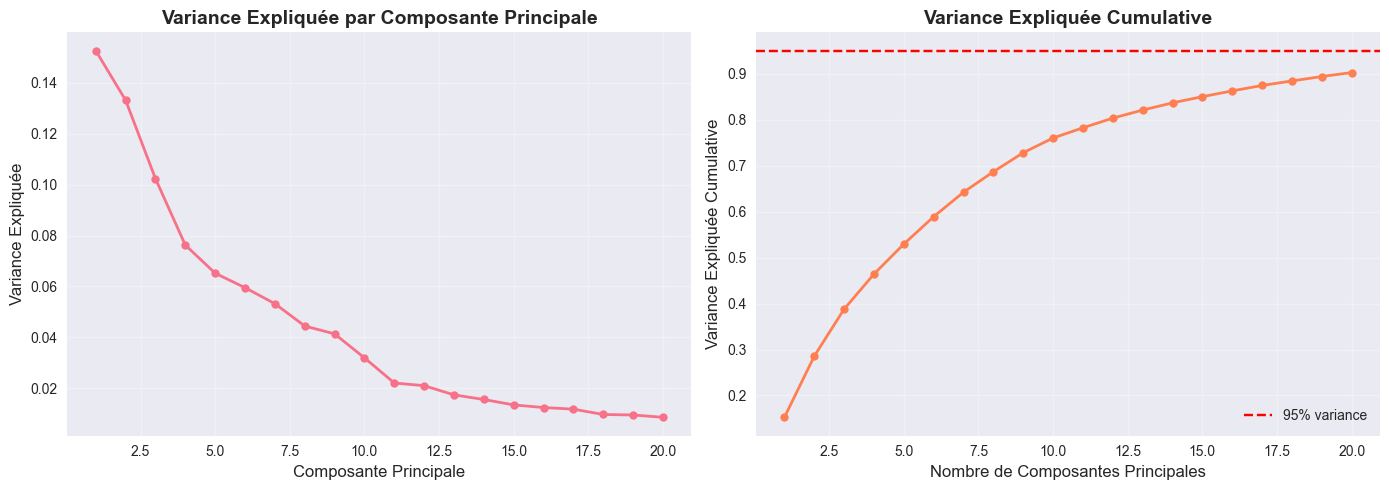


Nombre de composantes pour 95% de variance: 28


In [65]:
# Appliquer PCA
print("="*60)
print("ANALYSE PCA")
print("="*60)

# PCA pour visualisation 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance expliquée par PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance expliquée par PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Variance totale expliquée (2D): {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

# PCA pour visualisation 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\nVariance totale expliquée (3D): {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

# Analyser la variance expliquée pour différentes nombres de composantes
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculer la variance expliquée cumulative
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Visualiser la variance expliquée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance expliquée par composante
n_components_plot = min(20, len(pca_full.explained_variance_ratio_))
axes[0].plot(range(1, n_components_plot + 1),
             pca_full.explained_variance_ratio_[:n_components_plot], marker="o", linewidth=2, markersize=6)
axes[0].set_xlabel('Composante Principale', fontsize=12)
axes[0].set_ylabel('Variance Expliquée', fontsize=12)
axes[0].set_title('Variance Expliquée par Composante Principale', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, n_components_plot + 1),
             cumulative_variance[:n_components_plot], marker="o", linewidth=2, markersize=6, color="coral")
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].set_xlabel('Nombre de Composantes Principales', fontsize=12)
axes[1].set_ylabel('Variance Expliquée Cumulative', fontsize=12)
axes[1].set_title('Variance Expliquée Cumulative', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Trouver le nombre de composantes pour 95% de variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNombre de composantes pour 95% de variance: {n_components_95}")



### Visualisation pca 2d

Visualisons les données en 2D avec PCA pour voir si les classes sont séparables.



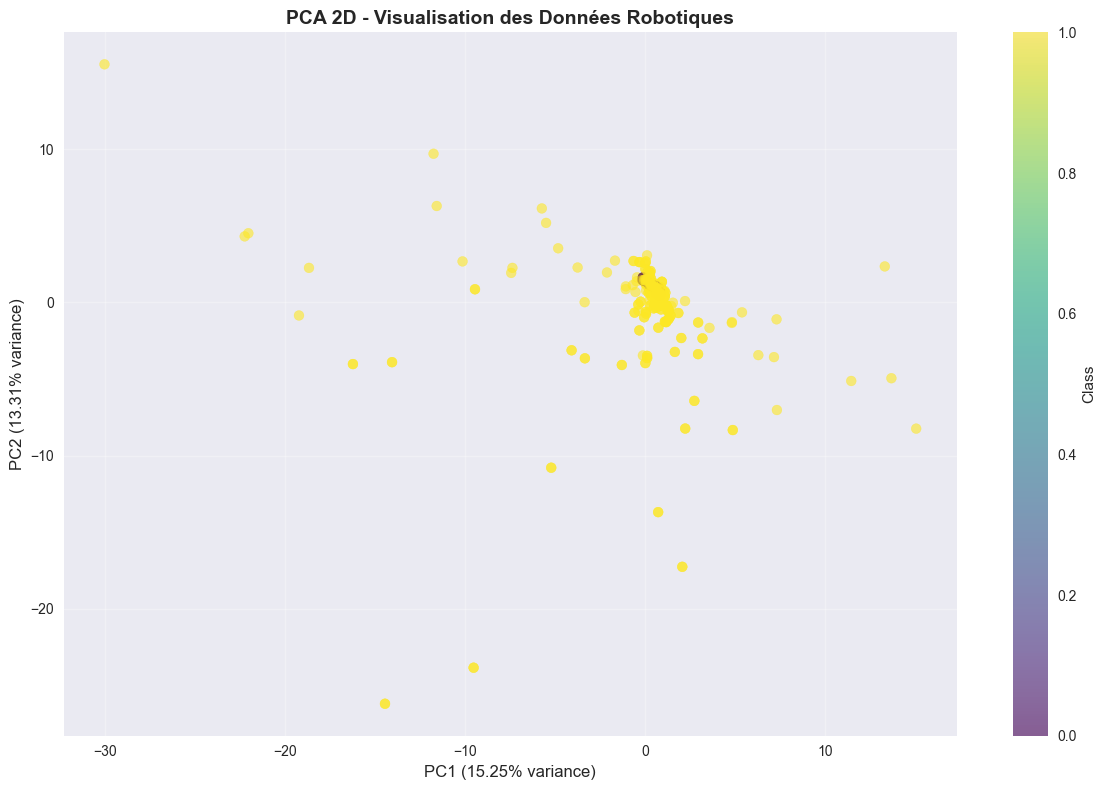


Explained Variance:
  PC1: 15.25%
  PC2: 13.31%
  Total: 28.56%


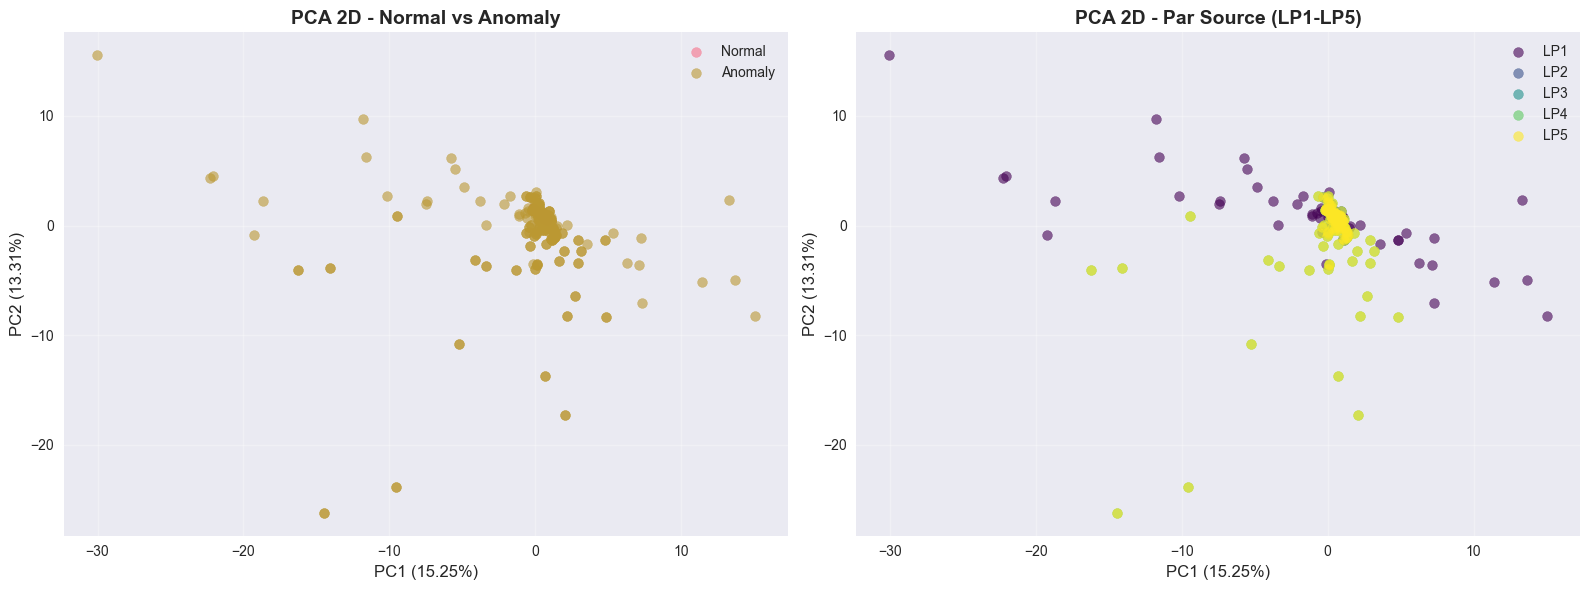

In [66]:
# Visualisation PCA 2D
plot_pca(X_scaled, y, n_components=2, 
         title="PCA 2D - Visualisation des Données Robotiques",
         figsize=(12, 8))

# Visualisation avec plus de détails
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Par classe binaire
for label_val in [0, 1]:
    mask = y == label_val
    label_name = 'Normal' if label_val == 0 else 'Anomaly'
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                   label=label_name, alpha=0.6, s=50)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
axes[0].set_title('PCA 2D - Normal vs Anomaly', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Par source (LP1-LP5)
if 'source' in df.columns:
    sources = df['source'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(sources)))
    for i, source in enumerate(sources):
        mask = df['source'] == source
        axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                       label=source, alpha=0.6, s=50, c=[colors[i]])

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
axes[1].set_title('PCA 2D - Par Source (LP1-LP5)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Visualisation pca 3d

Visualisons les données en 3D avec PCA pour une meilleure compréhension de la structure.



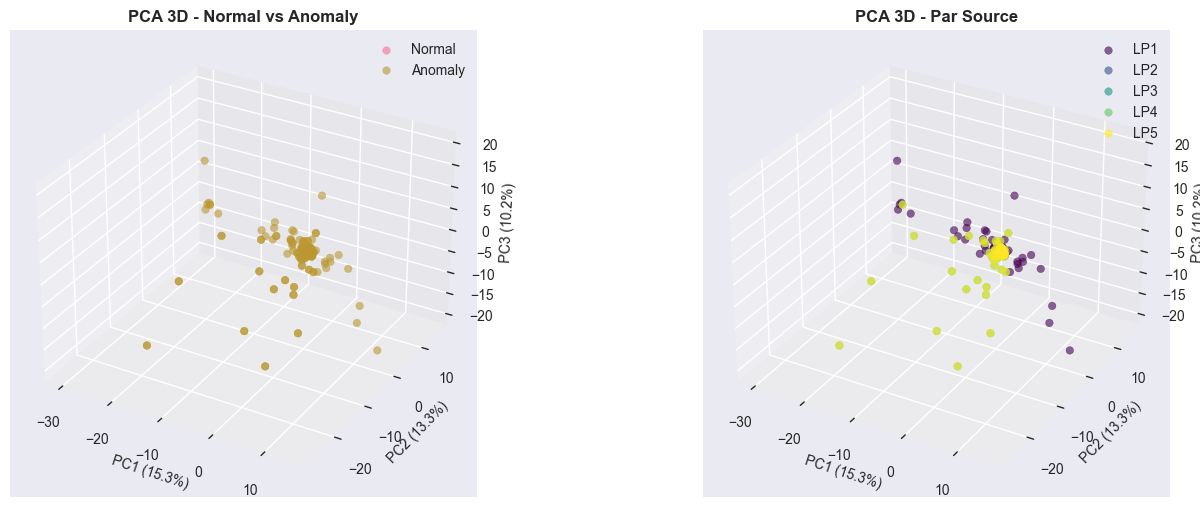


Variance expliquée par les 3 premières composantes:
  PC1: 15.25%
  PC2: 13.31%
  PC3: 10.23%
  Total: 38.79%


In [67]:
# Visualisation PCA 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))

# Vue 1: Par classe binaire
ax1 = fig.add_subplot(221, projection='3d')
for label_val in [0, 1]:
    mask = y == label_val
    label_name = 'Normal' if label_val == 0 else 'Anomaly'
    ax1.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               label=label_name, alpha=0.6, s=30)
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax1.set_title('PCA 3D - Normal vs Anomaly', fontsize=12, fontweight='bold')
ax1.legend()

# Vue 2: Par source (si disponible)
if 'source' in df.columns:
    ax2 = fig.add_subplot(222, projection='3d')
    sources = df['source'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(sources)))
    for i, source in enumerate(sources):
        mask = df['source'] == source
        ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                   label=source, alpha=0.6, s=30, c=[colors[i]])
    ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
    ax2.set_title('PCA 3D - Par Source', fontsize=12, fontweight='bold')
    ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nVariance expliquée par les 3 premières composantes:")
print(f"  PC1: {pca_3d.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca_3d.explained_variance_ratio_[1]*100:.2f}%")
print(f"  PC3: {pca_3d.explained_variance_ratio_[2]*100:.2f}%")
print(f"  Total: {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")



## 5. création de features statistiques

Créons des features statistiques pour chaque instance :
- mean, std, min, max : Statistiques de base
- skew, kurtosis : Forme de la distribution
- Sur les 15 échantillons par capteur (6 capteurs)

### Contexte robotique : signification des features statistiques

- Mean : Valeur moyenne du signal (force/couple moyen)
- Std : Variabilité du signal (stabilité du mouvement)
- Min/Max : Valeurs extrêmes (pics, collisions)
- Skew : Asymétrie du signal (distribution déséquilibrée)
- Kurtosis : Aplatissement du signal (présence de pics)

Ces features capturent les caractéristiques essentielles des signaux temporels et sont plus robustes au bruit que les valeurs brutes.



In [68]:
# Créer the features statistiques
print("="*60)
print("CRÉATION DE FEATURES STATISTIQUES")
print("="*60)

# Utiliser the data originales (non standardisées) pour the features statistiques
df_stats = create_statistical_features(df, samples_per_sensor=15, num_sensors=6)

print(f"\n Features statistiques créées!")
print(f"Shape du DataFrame avec features statistiques: {df_stats.shape}")
print(f"\nColonnes des features statistiques:")
stat_cols = [col for col in df_stats.columns if col not in ["source", "label", "label_binary", "label_encoded", "label_original"]]
# Ensure only numeric columns
stat_cols = [col for col in stat_cols if df_stats[col].dtype in [np.int64, np.float64]]
print(f"  - {len(stat_cols)} features statistiques")
print(f"  - Exemples: {stat_cols[:6]}")

# Afficher quelques exemples
print(f"\nPremières lignes avec features statistiques:")
print(df_stats[stat_cols[:10]].head())



CRÉATION DE FEATURES STATISTIQUES
Creating statistical features...
✅ Statistical features created: 53 columns
   Original features: 90
   Statistical features: 48

 Features statistiques créées!
Shape du DataFrame avec features statistiques: (463, 53)

Colonnes des features statistiques:
  - 48 features statistiques
  - Exemples: ['Fx_mean', 'Fx_std', 'Fx_min', 'Fx_max', 'Fx_range', 'Fx_skew']

Premières lignes avec features statistiques:
    Fx_mean    Fx_std  Fx_min  Fx_max  Fx_range   Fx_skew  Fx_kurtosis  \
0 -0.933333  0.249444    -1.0     0.0       1.0  3.474396    10.071429   
1 -0.866667  0.956847    -3.0     0.0       3.0 -1.181740     0.564002   
2 -0.666667  0.596285    -1.0     1.0       2.0  1.607174     1.453125   
3 -0.400000  0.952190    -2.0     1.0       3.0 -0.055599    -0.939446   
4 -0.600000  0.879394    -2.0     2.0       4.0  1.482212     2.605826   

       Fx_trend   Fy_mean    Fy_std  
0 -2.142857e-02 -0.866667  0.339935  
1  2.090877e-17 -0.666667  2.149935 

### Analyse des features statistiques

Analysons la distribution et l'importance des features statistiques.



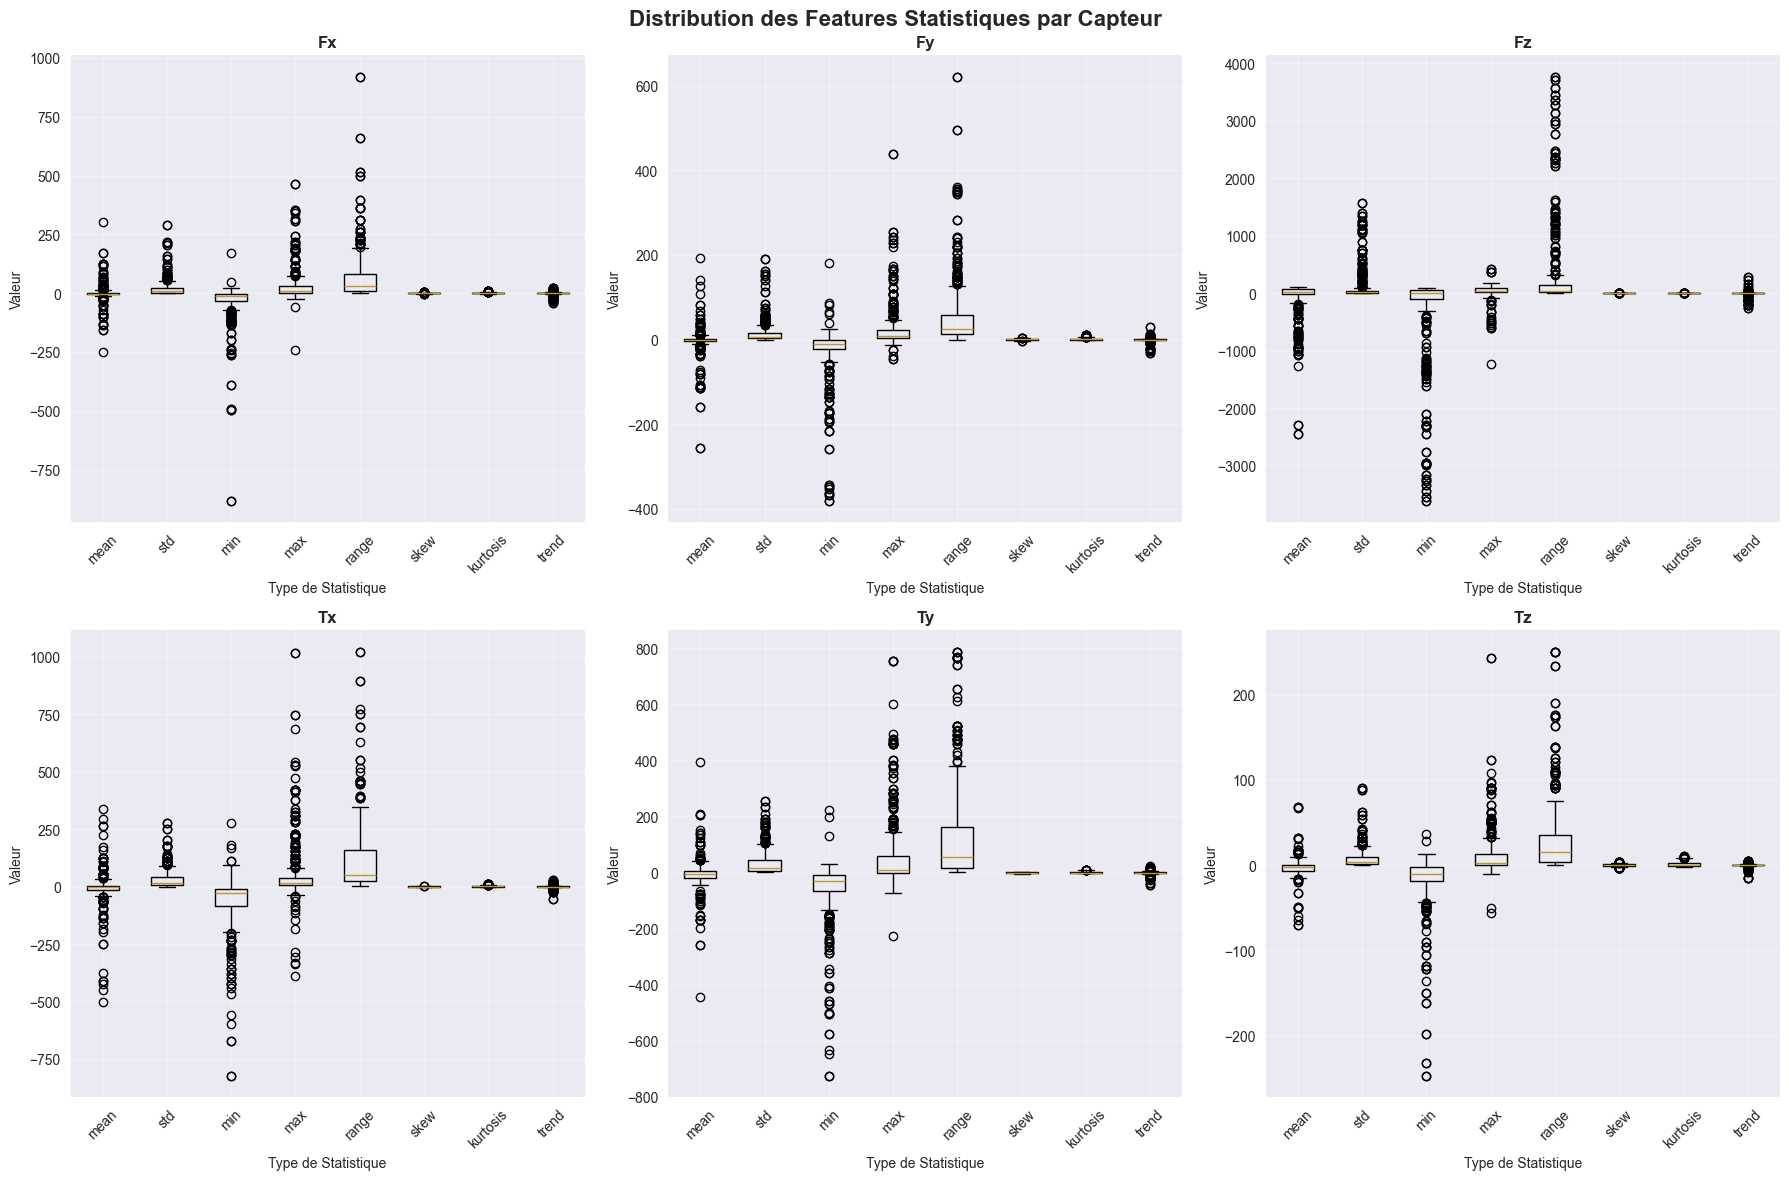


Comparaison des features statistiques: Normal vs Anomaly

Moyennes - Normal: 3.9033
Moyennes - Anomaly: 14.4351

Écart-type - Normal: 5.7087
Écart-type - Anomaly: 98.0035


In [69]:
# Analyser the features statistiques par capteur
sensor_names = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
stat_types = ['mean', 'std', 'min', 'max', 'skew', 'kurtosis']

# Visualiser la distribution des features statistiques par capteur
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution des Features Statistiques par Capteur', 
             fontsize=16, fontweight='bold')

for i, sensor_name in enumerate(sensor_names):
    row = i // 3
    col = i % 3
    
    # Extraire the features pour ce capteur
    sensor_stat_cols = [col for col in stat_cols if col.startswith(f'{sensor_name}_')]
    
    # Visualiser la distribution des statistiques
    sensor_stats = df_stats[sensor_stat_cols].values
    
    # Boxplot
    axes[row, col].boxplot(sensor_stats, labels=[s.replace(f'{sensor_name}_', '') for s in sensor_stat_cols])
    axes[row, col].set_title(f'{sensor_name}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Type de Statistique', fontsize=10)
    axes[row, col].set_ylabel('Valeur', fontsize=10)
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Comparer the features statistiques entre normal et anomaly
if 'label_binary' in df_stats.columns:
    print("\nComparaison des features statistiques: Normal vs Anomaly")
    normal_stats = df_stats[df_stats['label_binary'] == 0][stat_cols]
    anomaly_stats = df_stats[df_stats['label_binary'] == 1][stat_cols]
    
    print(f"\nMoyennes - Normal: {normal_stats.mean().mean():.4f}")
    print(f"Moyennes - Anomaly: {anomaly_stats.mean().mean():.4f}")
    print(f"\nÉcart-type - Normal: {normal_stats.std().mean():.4f}")
    print(f"Écart-type - Anomaly: {anomaly_stats.std().mean():.4f}")



## 6. pca sur les features statistiques

Appliquons PCA sur les features statistiques pour réduire encore plus la dimensionnalité et améliorer l'interprétabilité.



Variance expliquée par PC1 (features statistiques): 28.48%
Variance expliquée par PC2 (features statistiques): 9.58%
Variance totale expliquée: 38.06%


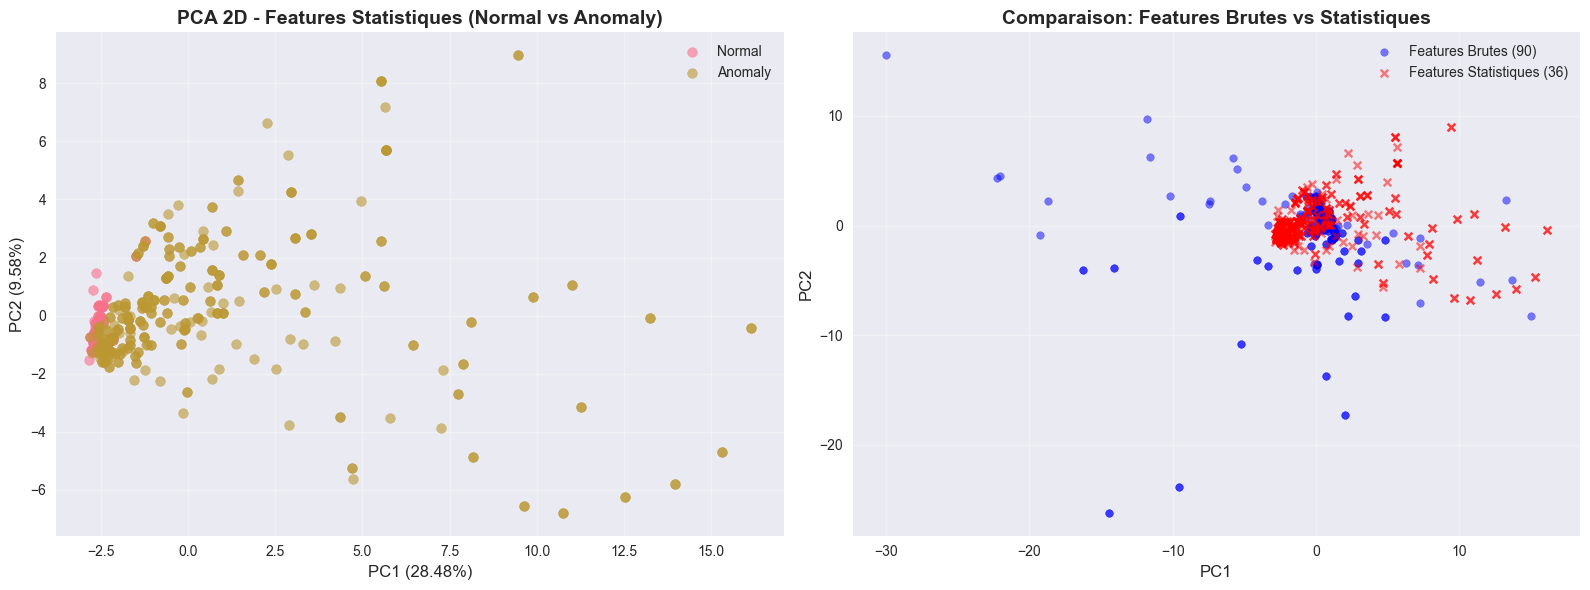

In [70]:
# Standardiser the features statistiques
X_stats = df_stats[stat_cols].values
scaler_stats = StandardScaler()
X_stats_scaled = scaler_stats.fit_transform(X_stats)

# Appliquer PCA sur the features statistiques
pca_stats = PCA(n_components=2)
X_stats_pca = pca_stats.fit_transform(X_stats_scaled)

print(f"Variance expliquée par PC1 (features statistiques): {pca_stats.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance expliquée par PC2 (features statistiques): {pca_stats.explained_variance_ratio_[1]*100:.2f}%")
print(f"Variance totale expliquée: {sum(pca_stats.explained_variance_ratio_)*100:.2f}%")

# Visualiser PCA 2D avec features statistiques
y_stats = df_stats['label_binary'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 2D avec features statistiques
for label_val in [0, 1]:
    mask = y_stats == label_val
    label_name = 'Normal' if label_val == 0 else 'Anomaly'
    axes[0].scatter(X_stats_pca[mask, 0], X_stats_pca[mask, 1], 
                   label=label_name, alpha=0.6, s=50)

axes[0].set_xlabel(f'PC1 ({pca_stats.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_stats.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
axes[0].set_title('PCA 2D - Features Statistiques (Normal vs Anomaly)', 
                 fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Comparaison: PCA sur features brutes vs features statistiques
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], label='Features Brutes (90)', 
               alpha=0.5, s=30, c='blue')
axes[1].scatter(X_stats_pca[:, 0], X_stats_pca[:, 1], label='Features Statistiques (36)', 
               alpha=0.5, s=30, c='red', marker='x')
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Comparaison: Features Brutes vs Statistiques', 
                 fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 7. discussion : transformation signal-versus-features

### Avantages des features statistiques

1. Réduction de dimensionnalité : De 90 à 36 features (réduction de 60%)
2. Robustesse au bruit : Les statistiques sont moins sensibles aux valeurs aberrantes
3. Interprétabilité : Chaque feature a une signification physique claire
4. Efficacité computationnelle : Moins de features = modèles plus rapides
5. Généralisation : Les patterns statistiques sont plus généralisables

### Limitations

1. Perte d'information temporelle : L'ordre temporel est perdu
2. Perte de détails : Les patterns subtils dans les séries temporelles peuvent être perdus
3. Choix des statistiques : Toutes les statistiques ne sont pas pertinentes

### Applications en robotique industrielle

- Détection de défaillances : Les features statistiques capturent les anomalies
- Maintenance prédictive : Les changements dans les statistiques prédisent les défaillances
- Optimisation de processus : Les statistiques révèlent les inefficacités
- Sécurité : La détection rapide permet d'arrêter le robot avant une collision



## 8. préparation pour les modèles

Préparons les données pour les modèles supervisés et non supervisés.

### Options de features

1. Features brutes standardisées (90 features) : Toutes les valeurs temporelles
2. Features statistiques (36 features) : Statistiques sur les 15 échantillons
3. PCA réduit : Composantes principales (réduction à n composantes)

 We utiliserons les features statistiques pour les modèles supervisés car elles offrent un bon compromis entre information et dimensionnalité.



In [71]:
# Préparer the data pour the models
print("="*60)
print("PRÉPARATION DES DONNÉES POUR LES MODÈLES")
print("="*60)

# Option 1: Features brutes standardisées
X_raw_scaled = X_scaled
print(f"Option 1 - Features brutes standardisées: {X_raw_scaled.shape}")

# Option 2: Features statistiques standardisées
X_stats_scaled = scaler_stats.transform(X_stats)
print(f"Option 2 - Features statistiques standardisées: {X_stats_scaled.shape}")

# Option 3: PCA sur features brutes (pour réduction)
pca_reduced = PCA(n_components=0.95)  # 95% de variance
X_pca_reduced = pca_reduced.fit_transform(X_scaled)
print(f"Option 3 - PCA réduit (95% variance): {X_pca_reduced.shape}")

# Sauvegarder the data preprocessées
print("\n Données preprocessées prêtes!")
print(f"  - Features brutes: {X_raw_scaled.shape}")
print(f"  - Features statistiques: {X_stats_scaled.shape}")
print(f"  - PCA réduit: {X_pca_reduced.shape}")
print(f"  - Labels: {y.shape}")

# Pour les notebooks suivants, we utiliserons the features statistiques
# because they offrent un bon compromis entre information et dimensionnalité



PRÉPARATION DES DONNÉES POUR LES MODÈLES
Option 1 - Features brutes standardisées: (463, 90)
Option 2 - Features statistiques standardisées: (463, 48)
Option 3 - PCA réduit (95% variance): (463, 28)

 Données preprocessées prêtes!
  - Features brutes: (463, 90)
  - Features statistiques: (463, 48)
  - PCA réduit: (463, 28)
  - Labels: (463,)


## 9. résumé et conclusions

### Résultats du preprocessing

1. Valeurs manquantes : Gérées (remplacement par médiane si nécessaire)
2. Standardisation : Données standardisées (mean=0, std=1)
3. PCA : Variance expliquée analysée et visualisée
4. Features statistiques : 36 features créées (6 capteurs × 6 statistiques)
5. Visualisation : PCA 2D et 3D pour comprendre la structure des données

### Insights pour la robotique industrielle

- Séparabilité : Les classes (normal vs anomaly) sont partiellement séparables en PCA
- Capteurs importants : Certains capteurs sont plus indicatifs que d'autres
- Patterns temporels : Les features statistiques capturent les caractéristiques essentielles
- Réduction de dimensionnalité : PCA permet de réduire de 90 à ~20-30 composantes avec 95% de variance

### Prochaines étapes

Dans le notebook suivant, we will:
- Entraîner des modèles supervisés (Logistic Regression, Random Forest, SVM, Gradient Boosting)
- Évaluer les performances avec métriques complètes (Accuracy, F1, Recall, Precision, ROC/AUC)
- Analyser les importances de features
- Interpréter quels capteurs sont les plus indicatifs d'une défaillance





In [72]:
# Sauvegarder the data preprocessées pour les notebooks suivants (optionnel)
# import pickle
# os.makedirs('../data/processed', exist_ok=True)
# with open('../data/processed/preprocessed_data.pkl', 'wb') as f:
#     pickle.dump({
#         'X_raw_scaled': X_raw_scaled,
#         'X_stats_scaled': X_stats_scaled,
#         'X_pca_reduced': X_pca_reduced,
#         'y': y,
#         'scaler': scaler,
#         'scaler_stats': scaler_stats,
#         'pca_reduced': pca_reduced,
#         'stat_cols': stat_cols,
#         'feature_cols': feature_cols
#     }, f)
# print("Données preprocessées sauvegardées!")

print(" Notebook 2 terminé!")
print("\nDonnées prêtes pour l'entraînement des modèles:")
print(f"  - Features statistiques: {X_stats_scaled.shape}")
print(f"  - Labels: {y.shape}")
print(f"  - Distribution: Normal={np.sum(y==0)}, Anomaly={np.sum(y==1)}")



 Notebook 2 terminé!

Données prêtes pour l'entraînement des modèles:
  - Features statistiques: (463, 48)
  - Labels: (463,)
  - Distribution: Normal=109, Anomaly=354
